<a href="https://colab.research.google.com/github/Daziega/ENAE-Machine-Learning/blob/Class_Continuation/CLUSTERING_CONCEPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Clustering
import pandas as pd

# Creating the raw dataset
data = {
    'Is_Simpson': [0, 1, 0, 1, 0, 1, 0, 1, 1],
    'School_Worker': [1, 0, 1, 0, 1, 0, 1, 0, 0],
    'Age': [42, 39, 30, 10, 45, 36, 50, 8, 83],
    'Income': [45000, 55000, 22000, 0, 60000, 12000, 28000, 0, 18000]
}
names = ['Edna', 'Homer', 'Otto', 'Bart', 'Skinner', 'Marge', 'Willie', 'Lisa', 'Abe']

df = pd.DataFrame(data, index=names)
df

,Is_Simpson,School_Worker,Age,Income
Edna,0,1,42,45000
Homer,1,0,39,55000
Otto,0,1,30,22000
Bart,1,0,10,0
Skinner,0,1,45,60000
Marge,1,0,36,12000
Willie,0,1,50,28000
Lisa,1,0,8,0
Abe,1,0,83,18000


In [2]:
# 1. Selecting role features for the analysis
X = df[['Is_Simpson', 'School_Worker']]
X

,Is_Simpson,School_Worker
Edna,0,1
Homer,1,0
Otto,0,1
Bart,1,0
Skinner,0,1
Marge,1,0
Willie,0,1
Lisa,1,0
Abe,1,0


In [3]:
# 2. Preprocessing: Verified that scales are identical [0, 1]
print("Preprocessing: Standardizing is not required for identical scales.")
X.agg(['min', 'max'])

Preprocessing: Standardizing is not required for identical scales.


,Is_Simpson,School_Worker
min,0,0
max,1,1


In [4]:
from scipy.spatial.distance import pdist, squareform

# 3. Generating the distance matrix
dist_array = pdist(X, metric='jaccard')
dist_matrix = pd.DataFrame(squareform(dist_array), index=X.index, columns=X.index)

# Displaying the distance matrix
dist_matrix

,Edna,Homer,Otto,Bart,Skinner,Marge,Willie,Lisa,Abe
Edna,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
Homer,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
Otto,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
Bart,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
Skinner,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
Marge,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
Willie,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
Lisa,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
Abe,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [5]:
from scipy.cluster.hierarchy import linkage, fcluster

# 4. Technique: Hierarchical with Ward linkage
Z = linkage(dist_array, method='ward')

# 5. Determination: Manually cutting the tree at k=2
clusters = fcluster(Z, 2, criterion='maxclust')
clusters

array([1, 2, 1, 2, 1, 2, 1, 2, 2], dtype=int32)

In [6]:
# 6. Joining results and sorting for interpretation
X_clus = X.copy()
X_clus['Cluster'] = clusters
X_clus.sort_values(by='Cluster')

,Is_Simpson,School_Worker,Cluster
Edna,0,1,1
Otto,0,1,1
Willie,0,1,1
Skinner,0,1,1
Bart,1,0,2
Homer,1,0,2
Marge,1,0,2
Lisa,1,0,2
Abe,1,0,2


EXAMPLE OF WORD EMBEDDING

In [7]:
%reset -f
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

words = ["Isabel", "reigned", "Castile", "and", "Fernando", "Aragon"]
w2i = {w:i for i,w in enumerate(words)} # Map word -> index

# Define pairs (Input -> Target)
# Isabel->reigned, reigned->Castile, Castile->and,
# and->Fernando, Fernando->reigned, reigned->Aragon
idx_inputs  = [0, 1, 2, 3, 4, 1]
idx_targets = [1, 2, 3, 4, 1, 5]

# Convert to One-Hot using the identity matrix (np.eye)
# This automatically creates vectors of size 6
X_train = np.eye(6)[idx_inputs]
y_train = np.eye(6)[idx_targets]


# Create two temporary DataFrames
df_x = pd.DataFrame(X_train, columns=words)
df_y = pd.DataFrame(y_train, columns=words)

# Join them into a single one using 'keys' to create a hierarchy in the columns
df_combined = pd.concat([df_x, df_y], axis=1, keys=['INPUT (X)', 'TARGET (y)'])

# Add a descriptive index to understand what we are training in each row
df_combined.index = [f"{words[i]} → {words[t]}" for i, t in zip(idx_inputs, idx_targets)]

print("Training Dataset (Full One-Hot):")
df_combined

Training Dataset (Full One-Hot):


INPUT (X)                                      TARGET (y)  \
                      Isabel reigned Castile  and Fernando Aragon     Isabel   
Isabel → reigned         1.0     0.0     0.0  0.0      0.0    0.0        0.0   
reigned → Castile        0.0     1.0     0.0  0.0      0.0    0.0        0.0   
Castile → and            0.0     0.0     1.0  0.0      0.0    0.0        0.0   
and → Fernando           0.0     0.0     0.0  1.0      0.0    0.0        0.0   
Fernando → reigned       0.0     0.0     0.0  0.0      1.0    0.0        0.0   
reigned → Aragon         0.0     1.0     0.0  0.0      0.0    0.0        0.0   

                                                         
                   reigned Castile  and Fernando Aragon  
Isabel → reigned       1.0     0.0  0.0      0.0    0.0  
reigned → Castile      0.0     1.0  0.0      0.0    0.0  
Castile → and          0.0     0.0  1.0      0.0    0.0  
and → Fernando         0.0     0.0  0.0      1.0    0.0  
Fernando → reigned     1.0     0.0  0.0      0.0    0.0  
reigned → Aragon       0.0     0.0  0.0      0.0    1.0

In [8]:
tf.random.set_seed(123)

model_w2v = tf.keras.Sequential([
    # W1 Layer: Embedding (6 inputs -> 2 neurons)
    # No bias for pure coordinates
    tf.keras.layers.Dense(2, input_dim=6, activation='linear',
                          use_bias=False, name="W1_Embeddings"),

    # W2 Layer: Prediction (2 inputs -> 6 outputs)
    tf.keras.layers.Dense(6, activation='softmax', name="W2_Prediction")
])

model_w2v.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ W1_Embeddings (Dense)           │ (None, 2)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ W2_Prediction (Dense)           │ (None, 6)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30 (120.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model_w2v.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("Training...")
history = model_w2v.fit(X_train, y_train, epochs=1500, verbose=0)

print(f"Final loss: {history.history['loss'][-1]:.4f}")
print(f"Final accuracy: {history.history['accuracy'][-1]:.4f}")

Training...
Final loss: 0.2311
Final accuracy: 0.8333


In [10]:
# Extract W1
weights_w1 = model_w2v.get_layer("W1_Embeddings").get_weights()[0]

# DataFrame to visualize
df_vectors = pd.DataFrame(weights_w1, index=words,
                          columns=['x', 'y'])

print("Learned vectors:")
df_vectors

Learned vectors:


,x,y
Isabel,1.908541,-1.796631
reigned,-2.023393,2.560806
Castile,-2.750433,-2.660040
and,1.943884,3.247048
Fernando,1.832506,-1.766935
Aragon,-0.353338,-0.374933


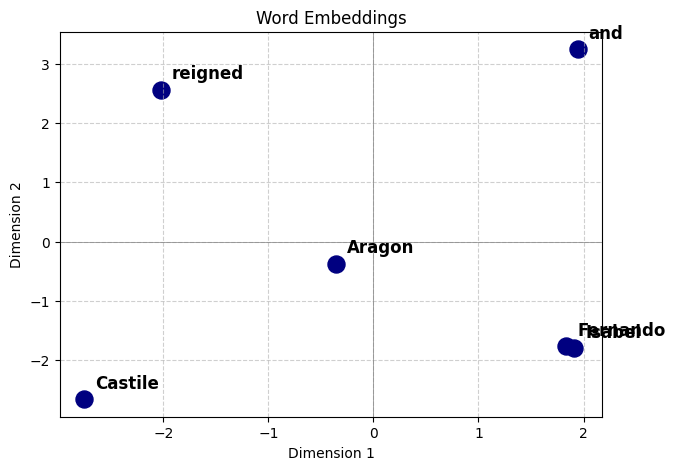

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(df_vectors['x'], df_vectors['y'], s=150, c='navy')

# Labels
for word, row in df_vectors.iterrows():
    plt.annotate(word, (row['x'], row['y']), xytext=(8, 8),
                 textcoords='offset points', fontsize=12, fontweight='bold')

plt.title("Word Embeddings")
plt.xlabel("Dimension 1"); plt.ylabel("Dimension 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.show()

HIERACHICAL CLUSTERING

In [12]:
import pandas as pd

# Data for 10 characters (including Mr. Burns)
data = {
    'Is_Simpson': [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    'School_Worker': [1, 0, 1, 0, 1, 0, 1, 0, 0, 0],
    'Age': [42, 39, 30, 10, 45, 36, 50, 8, 83, 104],
    'Income': [45000, 55000, 22000, 0, 60000, 12000, 28000, 0, 18000, 1000000]
}
names = ['Edna', 'Homer', 'Otto', 'Bart', 'Skinner', 'Marge', 'Willie', 'Lisa', 'Abe', 'Burns']

df = pd.DataFrame(data, index=names)
df

,Is_Simpson,School_Worker,Age,Income
Edna,0,1,42,45000
Homer,1,0,39,55000
Otto,0,1,30,22000
Bart,1,0,10,0
Skinner,0,1,45,60000
Marge,1,0,36,12000
Willie,0,1,50,28000
Lisa,1,0,8,0
Abe,1,0,83,18000
Burns,0,0,104,1000000


In [13]:
# Selecting binary features
X = df[['Is_Simpson', 'School_Worker']]
X

,Is_Simpson,School_Worker
Edna,0,1
Homer,1,0
Otto,0,1
Bart,1,0
Skinner,0,1
Marge,1,0
Willie,0,1
Lisa,1,0
Abe,1,0
Burns,0,0


In [14]:
print("Features are already on the same scale [0, 1]. No preprocessing required.")
X.describe().loc[['min', 'max']]

Features are already on the same scale [0, 1]. No preprocessing required.


,Is_Simpson,School_Worker
min,0.0,0.0
max,1.0,1.0


In [15]:
from scipy.spatial.distance import pdist, squareform

# Calculating Jaccard distance array and matrix
dist_array = pdist(X, metric='jaccard')
dist_matrix = pd.DataFrame(squareform(dist_array), index=X.index, columns=X.index)

# Preview of the distance between characters
dist_matrix

,Edna,Homer,Otto,Bart,Skinner,Marge,Willie,Lisa,Abe,Burns
Edna,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
Homer,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
Otto,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
Bart,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
Skinner,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
Marge,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
Willie,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
Lisa,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
Abe,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
Burns,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0


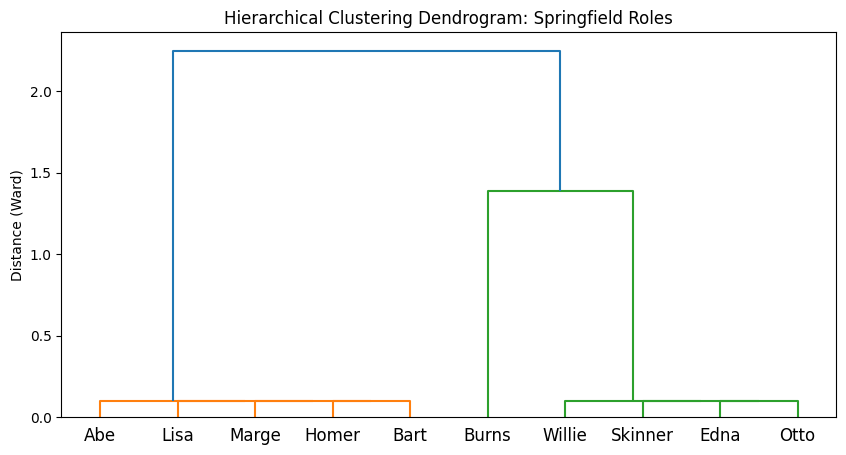

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Adding a tiny bit of noise so labels don't overlap at 0 distance
dist_array_jitter = dist_array + 0.1

# Applying Ward linkage
Z = linkage(dist_array_jitter, method='ward')

# Plotting the tree
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=X.index,  leaf_font_size=12)
plt.title("Hierarchical Clustering Dendrogram: Springfield Roles")
plt.ylabel("Distance (Ward)")
plt.show()

HIERACHICAL CLUSTERING IRIS CASE

In [17]:
import numpy as np
import pandas as pd
import random
from sklearn import datasets
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import fcluster

# we keep 50 iris records (without the species)
iris = datasets.load_iris()

random.seed(123)
sampling_indices = np.random.randint(0, 149, 50)

# Converting to DataFrame for better visualization
i_data = pd.DataFrame(iris.data[sampling_indices], columns=iris.feature_names)
i_data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,6.7,3.1,4.4,1.4
1,6.4,3.2,4.5,1.5
2,5.5,3.5,1.3,0.2
3,4.8,3.4,1.9,0.2
4,5.5,2.5,4.0,1.3


In [18]:
# obtain the distance matrix
dist_array = pdist(i_data, 'euclidean')

# we visualize the distance matrix as a DataFrame
dist_matrix = pd.DataFrame(squareform(dist_array))
dist_matrix.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.000000,0.346410,3.556684,3.374907,1.403567,3.478505,3.556684,1.489966,1.640122,3.160696,...,1.090871,3.488553,0.640312,3.656501,1.208305,1.208305,0.424264,3.488553,1.545962,0.640312
1,0.346410,0.000000,3.581899,3.324154,1.260952,3.484250,3.581899,1.378405,1.438749,3.182766,...,0.921954,3.485685,0.387298,3.642801,1.048809,1.048809,0.424264,3.485685,1.300000,0.387298
2,3.556684,3.581899,0.000000,0.927362,3.082207,0.964365,0.000000,4.944694,4.896938,0.547723,...,3.095158,0.346410,3.597221,0.547723,4.601087,4.601087,3.751000,0.346410,4.456456,3.597221
3,3.374907,3.324154,0.927362,0.000000,2.630589,1.417745,0.927362,4.655105,4.558509,1.009950,...,2.687006,0.707107,3.252691,0.547723,4.262628,4.262628,3.497142,0.707107,4.054627,3.252691
4,1.403567,1.260952,3.082207,2.630589,0.000000,3.272614,3.082207,2.368544,2.284732,2.831960,...,0.374166,2.989983,0.989949,2.976575,1.915724,1.915724,1.220656,2.989983,1.612452,0.989949


In [19]:
# perform clustering process with ward intra-cluster distance
# we use the dist_array calculated previously
clustering_model = linkage(dist_array, 'ward')

display("Obtained dendrogram model")

'Obtained dendrogram model'

In [20]:
# we cut the dendrogram forcing to obtain a maximum of 3 clusters
clusters = fcluster(clustering_model, 3, criterion='maxclust')

# output data joined into a single DataFrame
o_data = i_data.copy()
o_data["Cluster"] = clusters
o_data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,6.7,3.1,4.4,1.4,3
1,6.4,3.2,4.5,1.5,3
2,5.5,3.5,1.3,0.2,1
3,4.8,3.4,1.9,0.2,1
4,5.5,2.5,4.0,1.3,2


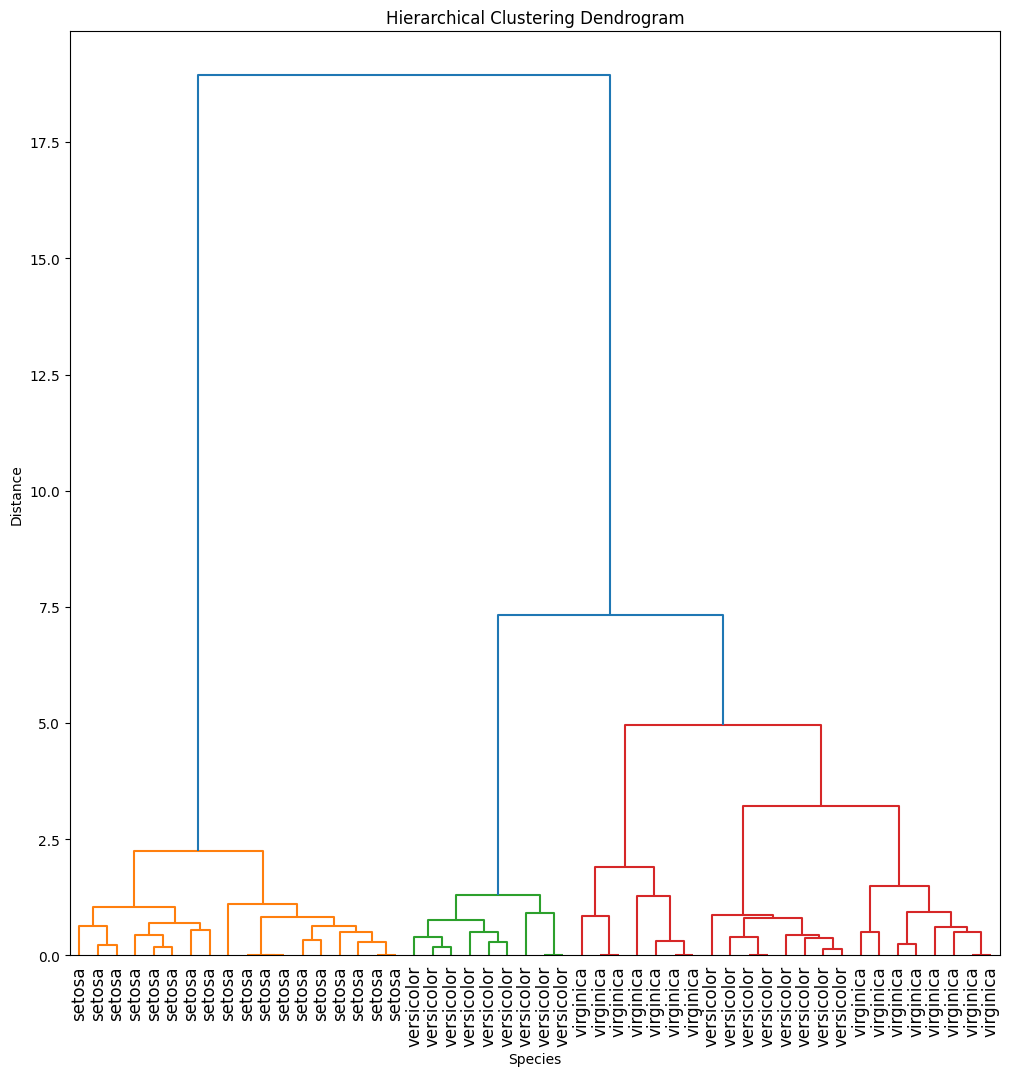

In [21]:
# plot dendrogram
plt.figure(figsize=(12, 12))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Species')
plt.ylabel('Distance')
d=dendrogram(clustering_model,color_threshold=5,
           leaf_rotation=90.,leaf_font_size=12.,
           labels=np.array(iris.target_names[iris.target[sampling_indices]]))
plt.show()

K-MEANS ALGORITHM: IRIS CASE

In [22]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# we keep the full iris dataset (150 records)
iris = datasets.load_iris()

# Converting to DataFrame for better visualization
i_data = pd.DataFrame(iris.data, columns=iris.feature_names)
i_data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [23]:
# In K-Means, instead of a distance matrix, we define the model configuration
# We specify 3 clusters (k=3) because we know there are 3 species
kmeans_model = KMeans(n_clusters=3, random_state=123, n_init=10)

# perform clustering process
# we fit the model with the complete data
kmeans_model.fit(i_data)

display("K-Means model fitted successfully")

'K-Means model fitted successfully'

In [24]:
# we obtain the labels assigned by the algorithm
clusters = kmeans_model.labels_

# output data joined into a single DataFrame
o_data = i_data.copy()
o_data["Cluster"] = clusters
o_data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [25]:
# Get centroids and convert to DataFrame
centers = kmeans_model.cluster_centers_
centers_df = pd.DataFrame(centers, columns=i_data.columns)
centers_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,6.850000,3.073684,5.742105,2.071053
1,5.006000,3.428000,1.462000,0.246000
2,5.901613,2.748387,4.393548,1.433871
